In [103]:
from ccka.models.kernel import KernelModel
from ccka.circuits.angleEmbeddingKernel import quackEmbeddingCircuit
from ccka.aligner.kta import fullKTA, centroidBasedKTA, quackKTA, randomKTA, greedyKTA
import pennylane as qml
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt 
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import time
import os
import warnings
warnings.filterwarnings("ignore")

In [104]:
def load_data(dataset_path):
    data = jnp.load(dataset_path, allow_pickle=True).item()
    X = jnp.asarray(data['x_train'])
    y = jnp.asarray(data['y_train'])
    x_test = jnp.asarray(data['x_test'])
    y_test = jnp.asarray(data['y_test'])

    X_combined = jnp.concatenate([X, x_test], axis=0)
    y_combined = jnp.concatenate([y, y_test], axis=0)

    return X_combined, y_combined

In [105]:
def run_experiment(dataset, dataset_path, centroids, num_iterations):

    print(f"Running centroidBasedKTA on {dataset} with centroids={centroids} and iterations={num_iterations}")
    
    X, y = load_data(dataset_path)

    kernel = quackEmbeddingCircuit(
                                num_qubits = 5,
                                reps = 6,
                                reupload = True
                        )
    init_weights = kernel.init_weights()
    model = KernelModel(circuit = kernel)

    aligner = centroidBasedKTA(
                    kernel_model= model,
                    data = X,
                    labels = y,
                    matrix_type='regular',
                    clustering='regular',
                    split_size=0.70,
                    centroids= centroids,
                    learning_rate=0.2,
                    centroid_lr=0.1,
                    sub_centroid_lr=0.1,
                    lambda_co=0.001,
                    lambda_kao=0.001,
                    epochs=num_iterations,
                    eps=0.001,
                    alpha=0.01
        )

    history = aligner.align()

    return history

In [106]:
result = run_experiment('checkerboard', '../data/checkerboard_dataset.npy', 4, 100)

Running centroidBasedKTA on checkerboard with centroids=4 and iterations=100


In [141]:
mc = [result['main_centroids'][0], result['main_centroids'][1], result['main_centroids'][2], result['main_centroids'][3]]
sc = [result['sub_centroids'][0], result['sub_centroids'][1], result['sub_centroids'][2], result['sub_centroids'][3]]
X, y = result['xtrain'], result['ytrain']

In [ ]:
from scipy.spatial.distance import cdist

def sub_centroid_attraction(current_pos, y, current_sc, lr_sub=0.15):

    new_pos = current_pos.copy()

    # split sub-centroids by class
    sc_pos = current_sc[:4]
    sc_neg = current_sc[4:]

    for i in range(len(current_pos)):

        point = current_pos[i]

        # choose class-specific sub-centroids
        if y[i] == 1:
            candidates = sc_pos
        else:
            candidates = sc_neg

        # nearest sub-centroid
        dists = np.linalg.norm(candidates - point, axis=1)
        nearest = candidates[np.argmin(dists)]

        # move toward nearest centroid
        new_pos[i] += lr_sub * (nearest - point)

    return new_pos

def main_centroid_attraction(current_pos, y, current_mc, lr_main=0.1):

    new_pos = current_pos.copy()

    for i in range(len(current_pos)):

        # choose class-specific centroid
        if y[i] == 1:
            target = current_mc[0]

        else:
            target = current_mc[1]

        # attraction update
        new_pos[i] += lr_main * (target - current_pos[i])

    return new_pos

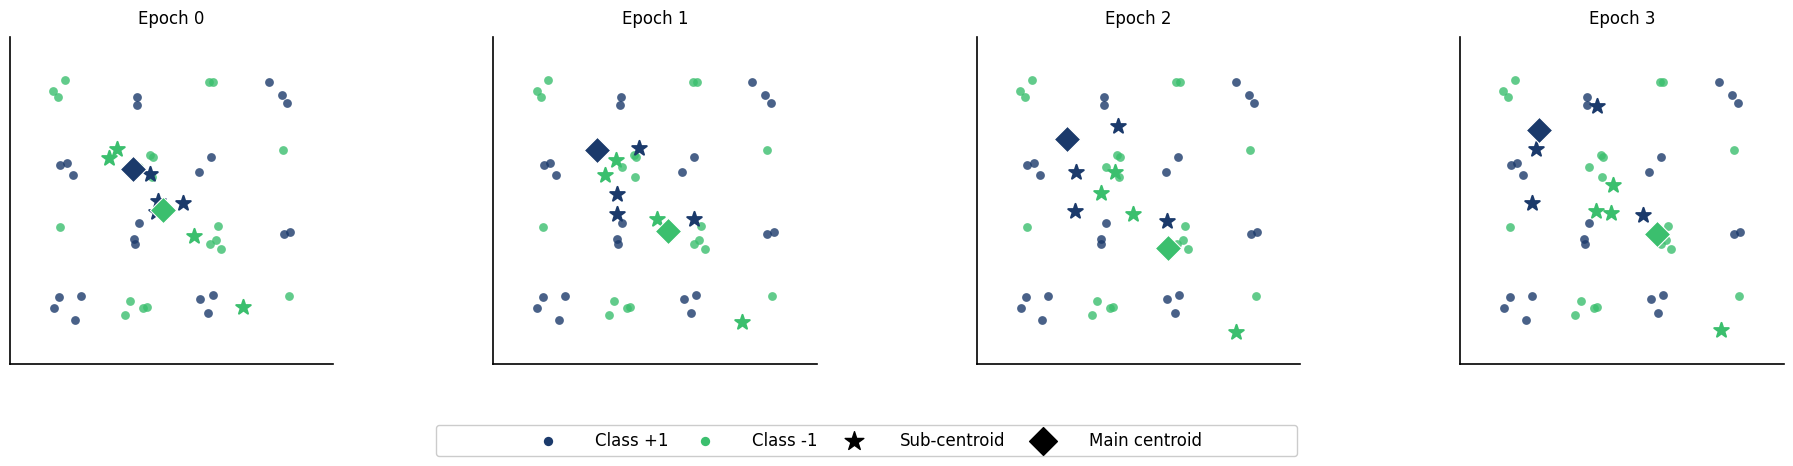

In [162]:
# ── Font / style settings ───────────────────────────────────────────────────
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Arial']
rcParams['mathtext.fontset'] = 'dejavusans'

# ── Colours ─────────────────────────────────────────────────────────────────
C_A = "#1B3A6B"   # navy blue
C_B = "#3BBF6E"   # green

# ── Figure with 4 panels ────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 4,
    figsize=(24, 4.8),
    facecolor='white'
)

# Make axes iterable if only one panel
axes = np.ravel(axes)

# ── Global axis limits from ALL coordinates ─────────────────────────────────
pad = 0.15

xmin = np.min(X[:, 0]) - pad
xmax = np.max(X[:, 0]) + pad

ymin = np.min(X[:, 1]) - pad
ymax = np.max(X[:, 1]) + pad

epochs_to_plot = [0, 1, 2, 3]
current_coords = X

# ── Plot each panel ─────────────────────────────────────────────────────────
for panel, ax in enumerate(axes):

    current_mc = mc[panel]
    current_sc = sc[panel]
    current_coords = update_coordinates(X, panel, lr_main=0.1, lr_sub=0.1)
    

    ax.set_facecolor('white')

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Equal aspect ratio
    ax.set_aspect('equal')

    # L-shaped frame
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

    for sp in ['bottom', 'left']:
        ax.spines[sp].set_color('black')
        ax.spines[sp].set_linewidth(1.2)

    ax.set_xticks([])
    ax.set_yticks([])

    # ── DATA POINTS ─────────────────────────────────────────────────────────
    ax.scatter( current_coords[y == 1, 0], current_coords[y == 1, 1], s=40, color=C_A, zorder=2, linewidths=0, alpha=0.80)
    ax.scatter( current_coords[y == -1, 0], current_coords[y == -1, 1], s=40, color=C_B, zorder=2, linewidths=0, alpha=0.80)

    # ── SUB-CENTROIDS ──────────────────────────────────────────────────────
    ax.scatter( current_sc[:4, 0], current_sc[:4, 1], s=120, marker='*', color=C_A, linewidths=1.5, zorder=4)
    ax.scatter( current_sc[4:, 0], current_sc[4:, 1], s=120, marker='*', color=C_B, linewidths=1.5, zorder=4)

    # ── MAIN CENTROIDS ─────────────────────────────────────────────────────
    ax.scatter( current_mc[0, 0], current_mc[0, 1], s=180, marker='D', color=C_A, edgecolors='white', linewidths=0.8, zorder=5)
    ax.scatter( current_mc[1, 0], current_mc[1, 1], s=180, marker='D', color=C_B, edgecolors='white', linewidths=0.8, zorder=5)

    # Optional title
    ax.set_title(f"Epoch {epochs_to_plot[panel]}", fontsize=12, pad=10)
    

# ── Legend ──────────────────────────────────────────────────────────────────
leg_handles = [

    plt.scatter([], [], s=0,
                color=C_A,
                linewidths=0,
                label=" "),

    plt.scatter([], [], s=45,
                color=C_A,
                linewidths=0,
                label="Class +1"),

    plt.scatter([], [], s=45,
                color=C_B,
                linewidths=0,
                label="Class -1"),

    plt.scatter([], [], s=200,
                marker='*',
                color='black',
                label="Sub-centroid"),

    plt.scatter([], [], s=200,
                marker='D',
                color='black',
                label="Main centroid"),

    plt.scatter([], [], s=0,
                color=C_A,
                linewidths=0,
                label=" "),
]

fig.legend( handles=leg_handles, loc='lower center', ncol=6, fontsize=12, frameon=True, framealpha=1.0, edgecolor='#CCCCCC', 
            bbox_to_anchor=(0.5, -0.01), columnspacing=1.2, handletextpad=1.8)

# ── Layout ──────────────────────────────────────────────────────────────────
plt.subplots_adjust( wspace=0.18, bottom=0.20)

plt.show()